# PIN vs VPIN — Pass 1 compare


In [1]:
from pathlib import Path
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = Path(os.environ.get('ARES_MICROSTRUCTURE') or (Path.home() / 'srv' / 'ares-microstructure')) / 'research' / 'books' / 'vpin_of'
OUT = BOOK / 'out'
FIGS = OUT / 'desk_synthesis' / 'figs'

def jload(rel):
    p = OUT / rel
    return json.loads(p.read_text()) if p.is_file() else {}

def jlines(rel):
    p = OUT / rel
    if not p.is_file():
        return []
    return [json.loads(ln) for ln in p.read_text().splitlines() if ln.strip()]

def show_fig(name, caption=None):
    p = FIGS / name
    if caption:
        display(Markdown(f'**{caption}** — `{p.relative_to(BOOK)}`'))
    if p.exists():
        display(Image(filename=str(p)))
    else:
        display(Markdown(f'*missing* `{p}` — run `scripts/build_notebook_figs.py`'))

dec = jload('pass4/decisions_pass4.json') or jload('pass3/decisions_pass3.json') or jload('pass2/decisions_pass2.json') or jload('vpin_panel/decisions.json')
dec_promote = jload('vpin_panel/decisions_panel_promote.json')
rows = jlines('vpin_panel/rows.jsonl')
panel_ext = jload('pass2/panel_hl_db_extended.json')
ok_rows = panel_ext if isinstance(panel_ext, list) and panel_ext else [r for r in rows if r.get('ok')]
p4 = jload('pass4/pass4_summary.json')
p3 = jload('pass3/pass3_summary.json')
p2 = jload('pass2/pass2_summary.json')
tag = 'pass4' if p4 else ('pass3' if p3 else ('pass2' if p2 else 'pass1'))
print(tag, 'n_ok', dec.get('n_ok'), 'promote n_ok', dec_promote.get('n_ok'), 'counts', dec.get('decision_counts'), 'book', dec.get('book_status'))


pass4 n_ok 226 promote n_ok 139 counts {'Promote': 5, 'Hold': 6} book FINAL


,venue,symbol,n_ok_days,mle,proxy,vpin_pooled,compare,day_mean_vpin_vs_pin_proxy_spearman
0,hyperliquid,ETH,27,"{'ok': True, 'n_days': 27, 'n_days_raw': 27, '...","{'n_days': 27, 'pin_proxy': 0.0664459896830331...","{'n_buckets': 298562, 'mean_vpin': 0.845497196...","{'pin': 0.17414844359655826, 'pin_ok': True, '...","{'n': 27.0, 'rho': 0.36568986568986567, 'lo': ..."
1,hyperliquid,BTC,27,"{'ok': True, 'n_days': 27, 'n_days_raw': 27, '...","{'n_days': 27, 'pin_proxy': 0.0565425296045885...","{'n_buckets': 623021, 'mean_vpin': 0.892204335...","{'pin': 0.25075021671383896, 'pin_ok': True, '...","{'n': 27.0, 'rho': 0.5231990231990232, 'lo': 0..."
2,hyperliquid,SOL,1,"{'ok': False, 'n_days': 0, 'n_days_raw': 1, 'P...","{'n_days': 1, 'pin_proxy': 0.00484385951249902...","{'n_buckets': 13727, 'mean_vpin': 0.8824808688...","{'pin': nan, 'pin_ok': False, 'pin_n_days': 0,...","{'n': 1.0, 'rho': nan}"
3,deribit,ETH,28,"{'ok': True, 'n_days': 28, 'n_days_raw': 28, '...","{'n_days': 28, 'pin_proxy': 0.0850352814201669...","{'n_buckets': 150105, 'mean_vpin': 0.761828626...","{'pin': 0.0728279577871283, 'pin_ok': True, 'p...","{'n': 28.0, 'rho': 0.24740010946907498, 'lo': ..."
4,deribit,BTC,28,"{'ok': True, 'n_days': 28, 'n_days_raw': 28, '...","{'n_days': 28, 'pin_proxy': 0.1314809616129425...","{'n_buckets': 345631, 'mean_vpin': 0.866210488...","{'pin': 0.17151902766566704, 'pin_ok': True, '...","{'n': 28.0, 'rho': -0.12315270935960591, 'lo':..."
5,deribit,SOL,28,"{'ok': True, 'n_days': 28, 'n_days_raw': 28, '...","{'n_days': 28, 'pin_proxy': 0.0580538013166761...","{'n_buckets': 142072, 'mean_vpin': 0.932086027...","{'pin': 0.2990959868910995, 'pin_ok': True, 'p...","{'n': 28.0, 'rho': 0.041050903119868636, 'lo':..."
6,kraken,ETH,29,"{'ok': True, 'n_days': 29, 'n_days_raw': 29, '...","{'n_days': 29, 'pin_proxy': 0.0457287917067740...","{'n_buckets': 187906, 'mean_vpin': 0.865569970...","{'pin': 0.16347732613387525, 'pin_ok': True, '...","{'n': 29.0, 'rho': 0.05073891625615764, 'lo': ..."
7,kraken,BTC,29,"{'ok': True, 'n_days': 29, 'n_days_raw': 29, '...","{'n_days': 29, 'pin_proxy': 0.0401594272531003...","{'n_buckets': 697326, 'mean_vpin': 0.930804805...","{'pin': 0.10702917427261517, 'pin_ok': True, '...","{'n': 29.0, 'rho': 0.012315270935960592, 'lo':..."
8,kraken,SOL,29,"{'ok': True, 'n_days': 29, 'n_days_raw': 29, '...","{'n_days': 29, 'pin_proxy': 0.0497489137526884...","{'n_buckets': 117333, 'mean_vpin': 0.861285176...","{'pin': 0.11684845663924263, 'pin_ok': True, '...","{'n': 29.0, 'rho': 0.4403940886699507, 'lo': 0..."


**Proxy Spearman by venue×symbol** — `out/desk_synthesis/figs/fig_pin_proxy_spearman.png`

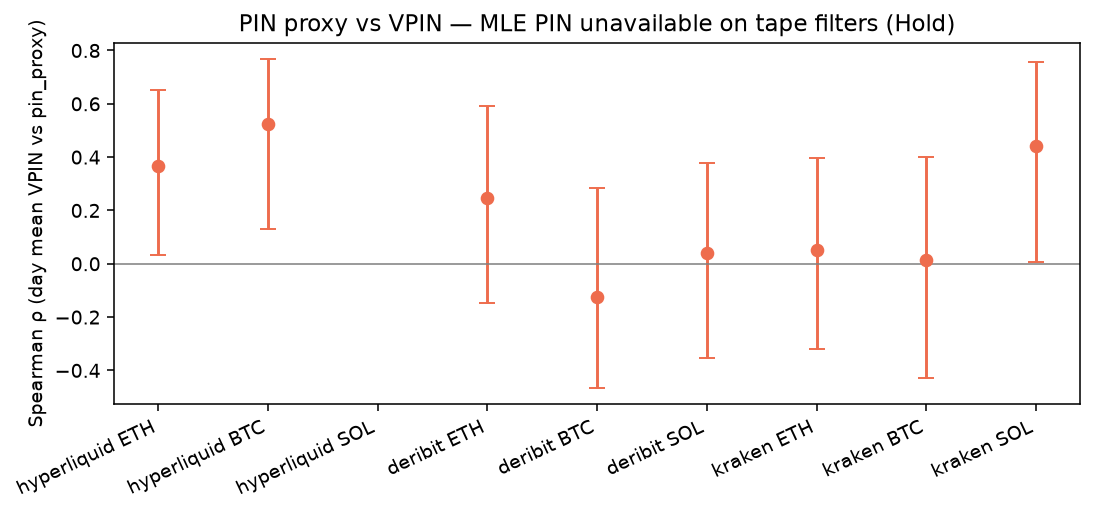

**Hold:** EHO PIN MLE returned 0 usable days after intensity filters; compare is diagnostic (pooled VPIN + day pin_proxy Spearman), not level-identified PIN.

In [2]:
blocks = jload('vpin_panel/pin_compare.json')
if isinstance(blocks, list):
    display(pd.DataFrame(blocks))
show_fig('fig_pin_proxy_spearman.png', 'Proxy Spearman by venue×symbol')
display(Markdown(
    '**Hold:** EHO PIN MLE returned 0 usable days after intensity filters; '
    'compare is diagnostic (pooled VPIN + day pin_proxy Spearman), not level-identified PIN.'
))
